In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Bio
import Bio.Seq
import numpy as np
import seaborn as sns

## Import Dataset

In [2]:
#df = pd.read_pickle("/Users/promero/Dropbox/projects/jared/GSF2636_Lewis_Pacbio/Fasta_Sequences_without_Indels/beta_activity.pkl")
df = pd.read_pickle("beta_activity.pkl")
df.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [3]:
# number of sequences
Nseq = len(df)
Nseq

960

In [4]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT = Bio.Seq.Seq(WT_DNA).translate()
WT

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

In [5]:
# Length of a sequence
N = len(df.iloc[0].sequence)
N

274

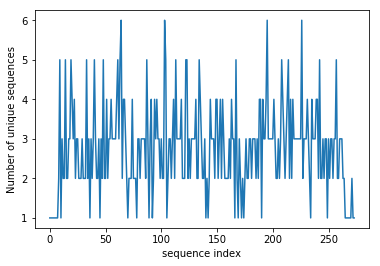

In [6]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [7]:
len(df.sequence.unique())

900

In [8]:
len(df)

960

In [9]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
print((df.first_stop != (N-1)).sum())
# print out wherever we have a stop in the middle
df[df.first_stop != (N-1)]

43


,sequence,count,response,first_stop
15,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1631,3,122
18,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1263,3,122
11,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,101,0,84
26,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,38,0,214
30,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,36,0,84
40,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,32,0,195
92,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,22,0,91
101,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,21,0,212
133,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17,0,167
146,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16,0,170


In [10]:
df[df.sequence == WT]

,sequence,count,response,first_stop
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2,273
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1124,1,273
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,781,0,273


In [11]:
df_nostop = df[df.first_stop == (len(WT) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,17456,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,11180,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10159,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3976,3


In [12]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,20885,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,13670,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,10801,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,6016,2


In [13]:
df_unique[["sequence", "response"]].groupby("response").count()

,sequence
response,
0,615
1,178
2,53
3,11


In [14]:
# Where is WT in this dataframe
# It should be at the top
df_unique[df_unique.sequence==WT]

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,29398,2


## Ordinal regression

In [15]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
import mord

In [16]:
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
#enc = OneHotEncoder(
#    drop=None, # don't drop columns 
#    sparse=False ) # setting to False for now

enc = OneHotEncoder()
OHE = enc.fit(design_cols)
X = OHE.transform(design_cols)
print(X.shape)
X

(857, 725)


<857x725 sparse matrix of type '<class 'numpy.float64'>'
	with 234818 stored elements in Compressed Sparse Row format>

In [17]:
enc.get_feature_names().size

725

In [18]:
mutations =  [WT[int(f[1:-2])]+f[1:-2]+f[-1] for f in enc.get_feature_names()]

In [19]:
y = df_unique.response.to_numpy()

In [20]:
# Try out model with alpha = 1.0
model = mord.LogisticAT(alpha=1.0)
model.fit(X, y)
model.score(X, y)

-0.13885647607934656

In [21]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [22]:
alphas = np.logspace(-6, 2, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=model, param_grid=dict(alpha=alphas), cv=5, iid='deprecated')
grid_cv.fit(X, y)

GridSearchCV(cv=5, estimator=LogisticAT(),
             param_grid={'alpha': array([1.00000000e-06, 7.74263683e-06, 5.99484250e-05, 4.64158883e-04,
       3.59381366e-03, 2.78255940e-02, 2.15443469e-01, 1.66810054e+00,
       1.29154967e+01, 1.00000000e+02])})

In [23]:
grid_cv.best_score_

-0.3658642730858153

In [24]:
# regularization parameter picked by CV
grid_cv.best_params_

{'alpha': 0.02782559402207126}

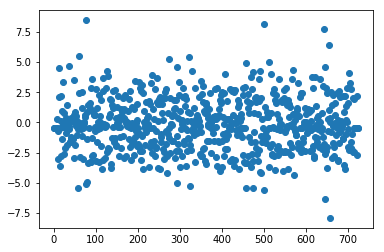

In [25]:
best_coefs = grid_cv.best_estimator_.coef_
plt.plot(best_coefs, 'o')

In [26]:
best_results = pd.DataFrame({'feature':mutations, 'coef':best_coefs})

In [27]:
best_results.sort_values('coef', ascending=False).head(10)

,feature,coef
77,E33K,8.463637
501,G191S,8.184781
643,L238Q,7.713310
655,K242K,6.412262
59,A25T,5.528332
322,K122I,5.453109
273,D104G,5.218134
513,W195L,4.975109
458,R175R,4.947092
36,H19H,4.711423


In [28]:
def show_design_response(col_num):
    return pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()
show_design_response(33)

aa  response
D   0             2
    1             1
E   0           601
    1           177
    2            53
    3            10
G   0             7
K   0             1
    3             1
V   0             4
dtype: int64

In [29]:
show_design_response(191)

aa  response
A   1             1
G   0           614
    1           176
    2            53
    3             9
R   0             1
S   1             1
    3             2
dtype: int64

In [30]:
best_results.sort_values('coef', ascending=True).head(10)

,feature,coef
657,K242R,-7.913112
644,L238V,-6.372952
500,G191R,-5.629722
57,A25A,-5.460188
475,T182S,-5.427245
457,R175H,-5.412593
324,K122R,-5.307600
76,E33G,-5.074285
293,V112A,-5.042659
78,E33V,-4.916417


In [31]:
show_design_response(238)

aa  response
L   0           613
    1           178
    2            53
    3             9
Q   0             1
    3             2
V   0             1
dtype: int64

In [32]:
show_design_response(214)

aa  response
E   0           609
    1           178
    2            51
    3            11
G   0             2
    2             2
K   0             1
V   0             3
dtype: int64

In [33]:
pd.set_option('display.max_rows', 1000)
best_results

,feature,coef
0,M0M,-0.465501
1,Q1Q,-0.465501
2,H2H,-0.465501
3,T3T,-0.465501
4,Y4Y,-0.465501
5,P5P,-0.465501
6,A6A,-0.465501
7,Q7Q,-0.465501
8,L8L,0.280205
9,L8P,-0.745706


In [34]:
WTscore = OHE.transform([WT,]) * model.coef_
AAs = 'ACDEFGHIKLMNPQRSTVWY'
score = pd.DataFrame([[np.nan] * len(WT) for a in AAs],index=list(AAs))
ms = []

In [35]:
for mut in mutations:
    WTres = mut[0]
    pos = int(mut[1:-1])
    mut_res = mut[-1]
    if WTres==mut_res:
        score.loc[WTres,pos] = 0
    else:
        mutant_seq = list(WT)
        mutant_seq[pos] = mut_res
        mut_score = OHE.transform([mutant_seq,]) * model.coef_
        diff = mut_score - WTscore
        score.loc[mut_res,pos] = diff[0]
        ms.append((mut,diff[0]))

In [36]:
ms = pd.DataFrame(ms,columns = ['mutation','score'])
ms.sort_values('score', ascending=False).head(10)

,mutation,score
33,A25T,4.470563
309,G191S,3.503394
404,L238Q,3.015973
216,Y130H,2.932187
176,R110C,2.915845
232,R139C,2.711713
337,A204V,2.706500
297,G185D,2.701800
200,K122I,2.474143
84,S58C,2.307479


In [37]:
ms.sort_values('score', ascending=True).head(10)

,mutation,score
282,R175H,-2.472927
414,K242R,-2.290127
406,F239L,-2.035796
302,N188I,-1.981472
407,F239S,-1.921125
443,F260S,-1.803252
442,F260L,-1.787721
18,H19Q,-1.756778
146,E94G,-1.755097
332,S201G,-1.744666


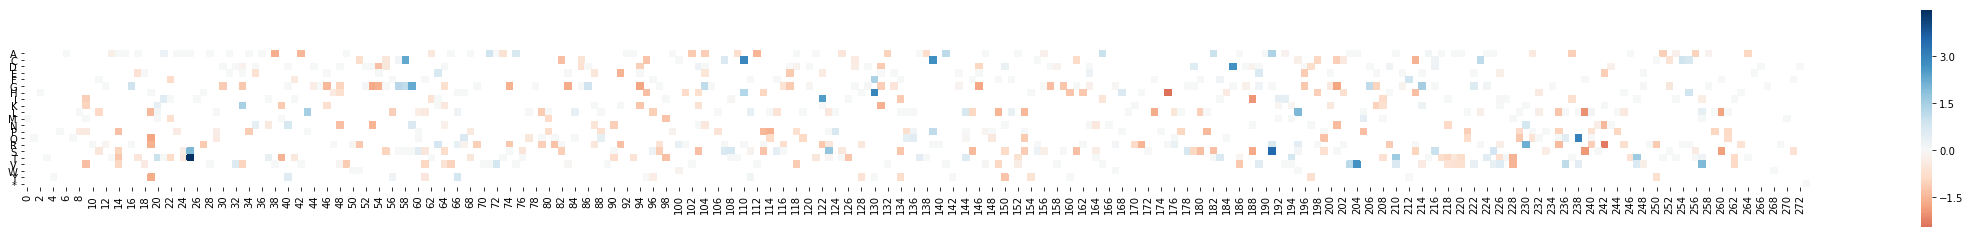

In [38]:
plt.figure(figsize=(40,4))
fig = sns.heatmap(score, center = 0, cmap = 'RdBu', square = True)
plt.savefig('score_heatmap.png', dpi=500)

In [40]:
# get a site-wise score for plotting onto structure 
pos_score = []
for pos in score:
    not_nan = [s for s in score[pos] if not np.isnan(s)]
    mx = max([(abs(s),s) for s in not_nan])[1] #max magnitude score 
    pos_score.append(mx)
    
pos_score = pos_score[:-1] # remove stop codon

In [41]:
# scale for plotting 
scaled = np.array(pos_score)
scaled[scaled>0] = scaled[scaled>0]/scaled.max() # rescale above 0 between 0 and 1
#scaled[scaled<-2000] = -2000 # set min floor
scaled[scaled<0] = scaled[scaled<0]/(-1*scaled.min()) # rescale below 0 to between -1 and 0
scaled = 100*(scaled - scaled.min())/(scaled.max()-scaled.min()) # rescale everything between 0 and 100

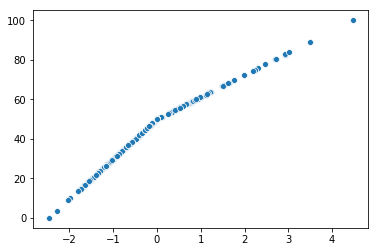

In [42]:
sns.scatterplot(pos_score,scaled)

In [43]:
pdb = open('3w20.pdb').read().strip().split('\n')
pdb = [l for l in pdb if len(l)>30 and (l[:6]=='HETATM' or l[:6].strip()=='ATOM') and l[21]=='A']
pdb = [l for l in pdb if l[17:20]!='HOH']
pdb = [l for l in pdb if l[17:20]!=' ZN']

In [44]:
tempFactor = dict((i+1,scaled[i]) for i in range(len(scaled)))
new_pdb = ''
for line in pdb:
    res_num = int(line[22:26])
    tf = ('%0.2f'%(tempFactor[res_num])).rjust(6) # format temp factor for PDB
    new_pdb+=line[:60]+tf+'\n'
    
open('SadH_activity_mapped.pdb','w').write(new_pdb)

134268